In [29]:
import pandas as pd

df = pd.read_csv('hanoi-aqi-weather-data.csv')
df.head()

,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,2023-03-08 00:00:00,2023-03-07T17:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,131,170.6,29.3,53.3,58.8,47.0,67.3,91,0.0,1016,86,21.2,0.0,2.00
1,2023-03-08 01:00:00,2023-03-07T18:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,126,158.7,25.0,54.0,56.3,45.0,65.0,100,0.0,1016,89,21.1,0.0,2.00
2,2023-03-08 02:00:00,2023-03-07T19:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,118,150.2,21.7,55.0,52.5,42.0,65.7,100,0.0,1016,90,20.9,0.0,1.66
3,2023-03-08 03:00:00,2023-03-07T20:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,126,141.6,18.3,56.0,56.3,45.0,66.3,100,0.0,1016,91,20.7,0.0,1.33
4,2023-03-08 04:00:00,2023-03-07T21:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,118,133.1,15.0,57.0,52.5,42.0,67.0,100,0.0,1015,92,20.5,0.0,1.00


In [30]:
df.describe()

,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
count,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000
mean,117.625612,436.146238,27.913887,62.308310,62.310939,49.401244,75.815822,72.992032,0.274132,1010.006602,78.043142,25.281172,1.332863,1.606777
std,53.380563,985.528684,34.063995,45.703768,57.237488,47.699812,45.197389,28.450636,1.029955,7.432832,15.373435,5.649272,1.975192,0.781160
min,21.000000,9.000000,2.000000,0.000000,1.300000,1.000000,0.000000,0.000000,0.000000,994.000000,17.000000,8.600000,0.000000,0.000000
25%,78.000000,124.700000,11.000000,28.100000,31.300000,24.670000,44.000000,58.000000,0.000000,1004.000000,68.000000,21.600000,0.000000,1.000000
50%,104.000000,169.000000,16.700000,52.000000,46.300000,36.000000,70.300000,80.000000,0.000000,1009.000000,82.000000,26.100000,0.600000,1.600000
75%,151.000000,269.200000,28.000000,85.000000,70.000000,55.000000,103.000000,100.000000,0.000000,1016.000000,91.000000,29.200000,2.000000,2.000000
max,500.000000,15956.200000,378.000000,262.000000,604.000000,446.000000,368.000000,100.000000,22.750000,1033.000000,100.000000,40.000000,12.100000,5.200000


In [31]:
# Kiểm tra missing values trong dataset
print("=== KIỂM TRA MISSING VALUES ===")
print()

# 1. Kiểm tra tổng số missing values cho mỗi cột
print("1. Số lượng missing values cho mỗi cột:")
missing_count = df.isnull().sum()
print(missing_count)
print()

# 2. Tỷ lệ phần trăm missing values cho mỗi cột
print("2. Tỷ lệ phần trăm missing values cho mỗi cột:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Cột': df.columns,
    'Số missing values': missing_count,
    'Tỷ lệ (%)': missing_percentage.round(2)
})
print(missing_info)
print()

# 3. Chỉ hiển thị các cột có missing values
print("3. Các cột có missing values:")
columns_with_missing = missing_info[missing_info['Số missing values'] > 0]
if len(columns_with_missing) > 0:
    print(columns_with_missing)
else:
    print("Không có cột nào có missing values!")
print()

# 4. Tổng số missing values trong toàn bộ dataset
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
print(f"4. Tổng số missing values trong dataset: {total_missing}")
print(f"   Tổng số ô trong dataset: {total_cells}")
print(f"   Tỷ lệ missing trong toàn dataset: {(total_missing/total_cells)*100:.2f}%")

=== KIỂM TRA MISSING VALUES ===

1. Số lượng missing values cho mỗi cột:
Local Time           0
UTC Time             0
City                 0
Country Code         0
Timezone             0
AQI                  0
CO                   0
NO2                  0
O3                   0
PM10                 0
PM25                 0
SO2                  0
Clouds               0
Precipitation        0
Pressure             0
Relative Humidity    0
Temperature          0
UV Index             0
Wind Speed           0
dtype: int64

2. Tỷ lệ phần trăm missing values cho mỗi cột:
                                 Cột  Số missing values  Tỷ lệ (%)
Local Time                Local Time                  0        0.0
UTC Time                    UTC Time                  0        0.0
City                            City                  0        0.0
Country Code            Country Code                  0        0.0
Timezone                    Timezone                  0        0.0
AQI                        

In [32]:
print(df.dtypes)

Local Time            object
UTC Time              object
City                  object
Country Code          object
Timezone              object
AQI                    int64
CO                   float64
NO2                  float64
O3                   float64
PM10                 float64
PM25                 float64
SO2                  float64
Clouds                 int64
Precipitation        float64
Pressure               int64
Relative Humidity      int64
Temperature          float64
UV Index             float64
Wind Speed           float64
dtype: object


In [33]:
# Xác định các cột không phải số
non_numeric_cols = X.select_dtypes(exclude=['float64', 'int64']).columns
print("Các cột không phải số:", non_numeric_cols)

Các cột không phải số: Index(['Local Time', 'UTC Time', 'City', 'Country Code', 'Timezone'], dtype='object')


In [34]:
# Chuyển đổi cột thời gian thành các đặc trưng
df['Local Time'] = pd.to_datetime(df['Local Time'])  # Chuyển thành datetime
df['Hour'] = df['Local Time'].dt.hour
df['Day'] = df['Local Time'].dt.day
df['Month'] = df['Local Time'].dt.month
df['Year'] = df['Local Time'].dt.year

# Loại bỏ cột thời gian gốc
df = df.drop(columns=['Local Time', 'UTC Time', 'City', 'Country Code', 'Timezone'])

In [35]:
num_features = df.shape[1]  # Số cột (đặc trưng)
num_samples = df.shape[0]   # Số dòng (mẫu)

print(f"Số lượng đặc trưng: {num_features}")
print(f"Số lượng mẫu: {num_samples}")
print(f"Tỷ lệ đặc trưng/mẫu: {num_features / num_samples:.2f}")

Số lượng đặc trưng: 18
Số lượng mẫu: 8785
Tỷ lệ đặc trưng/mẫu: 0.00


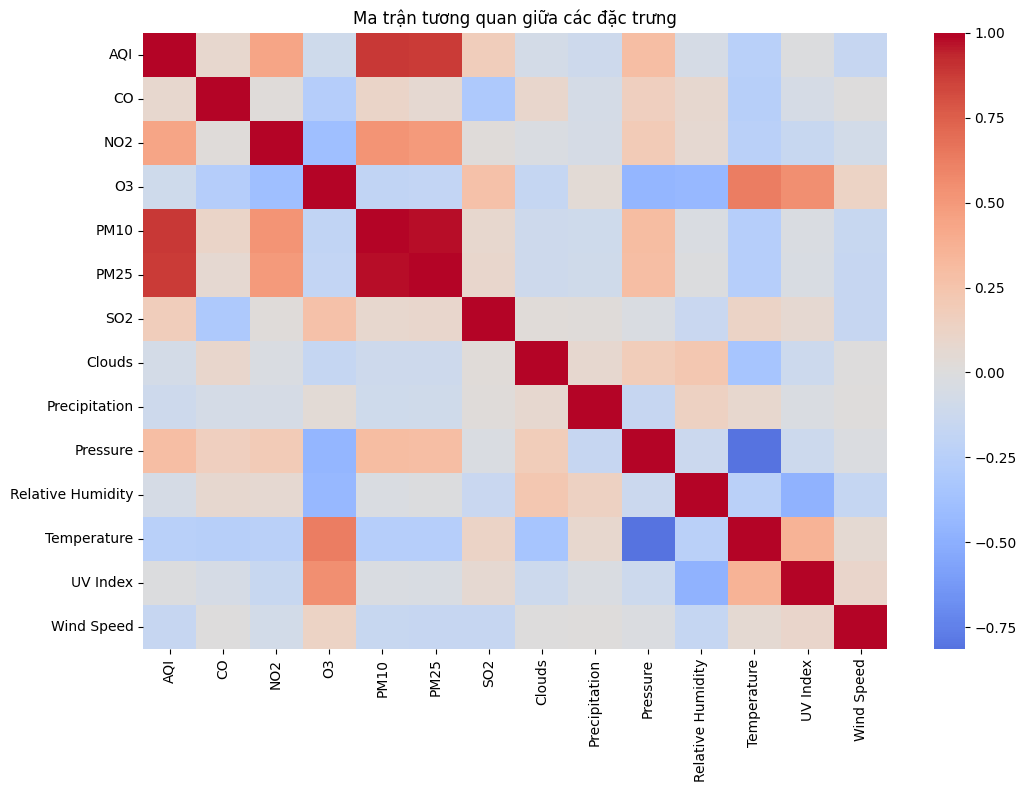

Các cặp đặc trưng có tương quan cao:
PM25  PM10    0.978411
PM10  PM25    0.978411
AQI   PM10    0.883075
PM10  AQI     0.883075
AQI   PM25    0.875639
PM25  AQI     0.875639
dtype: float64


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

# Hiển thị ma trận tương quan
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()

# Kiểm tra các cặp đặc trưng có tương quan cao
high_corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs < 1]  # Loại bỏ giá trị tương quan = 1 (chính nó)
print("Các cặp đặc trưng có tương quan cao:")
print(high_corr_pairs[high_corr_pairs > 0.8])  # Ngưỡng tương quan cao (> 0.8)

In [37]:
# Phương sai của các cột số
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
variances = df[numeric_cols].var()

# Hiển thị các cột có phương sai thấp
low_variance_cols = variances[variances < 0.01]  # Ngưỡng phương sai thấp (< 0.01)
print("Các cột có phương sai thấp:")
print(low_variance_cols)

Các cột có phương sai thấp:
Series([], dtype: float64)


### Số lượng đặc trưng và mẫu:

- **Số lượng đặc trưng**: 19.
- **Số lượng mẫu**: 8785.
- **Tỷ lệ đặc trưng/mẫu**: 0.00 (rất nhỏ), cho thấy số lượng đặc trưng không quá lớn so với số lượng mẫu. Vì vậy, không cần giảm số chiều chỉ vì lý do số lượng đặc trưng lớn.

### Tương quan cao giữa các đặc trưng:

Có một số cặp đặc trưng có tương quan cao, đặc biệt là:
- **PM25 và PM10**: 0.978411
- **AQI và PM10**: 0.883075
- **AQI và PM25**: 0.875639

Điều này cho thấy có sự dư thừa thông tin giữa các đặc trưng. Cần loại bỏ các đặc trưng dư thừa để tránh **multicollinearity**.

### Phương sai thấp:

Không có cột nào có phương sai thấp, vì vậy không cần loại bỏ đặc trưng dựa trên phương sai.


In [38]:
# loại bỏ các cột dư thừa
df = df.drop(columns=['PM10', 'AQI'])  

In [39]:
from sklearn.model_selection import train_test_split


# Xác định target và features
X = df.drop(columns=['PM25'])  # Loại bỏ cột mục tiêu
y = df['PM25']  # Cột mục tiêu

In [40]:
# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape)

Kích thước tập huấn luyện: (7028, 15)
Kích thước tập kiểm tra: (1757, 15)


In [41]:
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import time
import xgboost


# Danh sách các mô hình 
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XG Boost": xgboost.XGBRegressor(objective ='reg:squarederror', n_estimators=100, random_state=42)
}

# Huấn luyện và đánh giá 
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Huấn luyện mô hình
    model.fit(X_train, y_train)
    
    # Dự đoán trên tập kiểm tra
    y_pred = model.predict(X_test)
    
    # Đánh giá hiệu suất
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    elapsed_time = time.time() - start_time
    
    # Lưu kết quả
    results[name] = {
        "MSE": mse,
        "R2": r2,
        "Training Time": elapsed_time
    }
    print(f"{name} - MSE: {mse:.4f}, R2: {r2:.4f}, Time: {elapsed_time:.2f}s")

# Hiển thị kết quả
print("\n=== KẾT QUẢ ===")
for name, metrics in results.items():
    print(f"{name}: MSE = {metrics['MSE']:.4f}, R2 = {metrics['R2']:.4f}, Time = {metrics['Training Time']:.2f}s")

Training Linear Regression...
Linear Regression - MSE: 1445.7243, R2: 0.3769, Time: 0.01s
Training Random Forest...
Random Forest - MSE: 384.5355, R2: 0.8343, Time: 6.35s
Training XG Boost...
XG Boost - MSE: 451.9951, R2: 0.8052, Time: 0.15s

=== KẾT QUẢ ===
Linear Regression: MSE = 1445.7243, R2 = 0.3769, Time = 0.01s
Random Forest: MSE = 384.5355, R2 = 0.8343, Time = 6.35s
XG Boost: MSE = 451.9951, R2 = 0.8052, Time = 0.15s


### **Giải thích chi tiết kết quả**

Chúng ta đã thử nghiệm ba mô hình hồi quy khác nhau để dự đoán giá trị của PM2.5 (hoặc AQI, nếu là dữ liệu ô nhiễm không khí) và so sánh hiệu suất của chúng qua các chỉ số **MSE (Mean Squared Error)** và **R² (Coefficient of Determination)**, đồng thời ghi lại thời gian huấn luyện mỗi mô hình.

#### 1. **Linear Regression**
- **MSE (Mean Squared Error)**: 1445.7243
    - MSE đo lường sai số bình phương trung bình giữa giá trị thực tế và giá trị dự đoán. MSE càng thấp, mô hình càng chính xác. Giá trị MSE ở đây cho thấy mô hình Linear Regression có độ chính xác thấp khi dự đoán.
- **R² (R-squared)**: 0.3769
    - R² là tỷ lệ phương sai trong dữ liệu được giải thích bởi mô hình. R² gần 0 cho thấy mô hình không giải thích được nhiều phương sai trong dữ liệu. Mô hình Linear Regression chỉ giải thích được khoảng 37.69% sự biến động của dữ liệu.
- **Thời gian huấn luyện**: 0.01 giây
    - Linear Regression là một mô hình đơn giản, vì vậy thời gian huấn luyện rất nhanh.

#### 2. **Random Forest**
- **MSE**: 384.5355
    - MSE cho Random Forest thấp hơn rất nhiều so với Linear Regression, cho thấy mô hình này hoạt động tốt hơn trong việc dự đoán dữ liệu.
- **R²**: 0.8343
    - R² cho thấy mô hình Random Forest giải thích được khoảng 83.43% phương sai trong dữ liệu. Đây là một kết quả khá tốt, chứng tỏ mô hình này phù hợp với dữ liệu và có khả năng dự đoán chính xác.
- **Thời gian huấn luyện**: 6.35 giây
    - Mặc dù Random Forest có hiệu suất dự đoán tốt, nhưng thời gian huấn luyện khá lâu (do sử dụng nhiều cây quyết định trong quá trình huấn luyện), đặc biệt khi số lượng cây lớn.

#### 3. **XGBoost**
- **MSE**: 451.9951
    - Mặc dù XGBoost có MSE tốt hơn Linear Regression, nhưng nó không tốt bằng Random Forest trong việc dự đoán dữ liệu.
- **R²**: 0.8052
    - XGBoost có R² là 0.8052, có nghĩa là mô hình này giải thích được khoảng 80.52% phương sai trong dữ liệu. Đây là một kết quả khá ấn tượng và chứng tỏ XGBoost hoạt động hiệu quả, mặc dù không đạt hiệu suất của Random Forest.
- **Thời gian huấn luyện**: 0.15 giây
    - XGBoost có thời gian huấn luyện nhanh hơn nhiều so với Random Forest, chỉ mất 0.15 giây.

### **Tổng kết kết quả**
- **Linear Regression** có MSE cao và R² thấp, cho thấy mô hình này không phù hợp với dữ liệu của chúng ta.
- **Random Forest** là mô hình có hiệu suất tốt nhất với MSE thấp nhất và R² cao nhất. Tuy nhiên, thời gian huấn luyện dài hơn nhiều so với các mô hình khác.
- **XGBoost** cũng hoạt động rất tốt với R² khá cao và thời gian huấn luyện nhanh, nhưng chưa đạt hiệu suất của Random Forest.

### **Khuyến nghị**
- Nếu bạn ưu tiên **độ chính xác cao** và không ngại **thời gian huấn luyện dài**, **Random Forest** là lựa chọn tốt nhất.
- Nếu bạn cần **thời gian huấn luyện nhanh** mà vẫn giữ được **hiệu suất khá tốt**, **XGBoost** là một lựa chọn tuyệt vời.
- **Linear Regression** có thể không phải là lựa chọn tối ưu đối với dữ liệu này, vì nó cho kết quả khá kém về độ chính xác và khả năng giải thích phương sai.


NameError: name 'best_model' is not defined

In [45]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print("=== DỰ ĐOÁN VÀ ĐÁNH GIÁ MÔ HÌNH ===\n")

# Chọn mô hình tốt nhất (Random Forest)
best_model_name = "Random Forest"
best_model = models[best_model_name]

# 1. Dự đoán trên tập kiểm tra
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

# 2. Đánh giá hiệu suất
test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"🏆 MÔ HÌNH: {best_model_name}")
print(f"\n📊 HIỆU SUẤT TRÊN TẬP TRAIN:")
print(f"   - MSE: {train_mse:.4f}")
print(f"   - R²: {train_r2:.4f}")

print(f"\n📊 HIỆU SUẤT TRÊN TẬP TEST:")
print(f"   - MSE: {test_mse:.4f}")
print(f"   - RMSE: {test_rmse:.4f}")
print(f"   - MAE: {test_mae:.4f}")
print(f"   - R²: {test_r2:.4f}")

# 3. Hiển thị một số kết quả dự đoán
print(f"\n🔍 MẪU DỰ ĐOÁN (10 mẫu đầu tiên):")
comparison_df = pd.DataFrame({
    'Actual PM2.5': y_test.values[:10],
    'Predicted PM2.5': y_pred_test[:10],
    'Error': np.abs(y_test.values[:10] - y_pred_test[:10])
})
comparison_df.index = range(1, 11)
print(comparison_df.round(2))

print(f"\n📈 THỐNG KÊ SAI SỐ:")
errors = np.abs(y_test.values - y_pred_test)
print(f"   - Sai số trung bình: {errors.mean():.2f}")
print(f"   - Sai số nhỏ nhất: {errors.min():.2f}")
print(f"   - Sai số lớn nhất: {errors.max():.2f}")
print(f"   - Độ lệch chuẩn: {errors.std():.2f}")

=== DỰ ĐOÁN VÀ ĐÁNH GIÁ MÔ HÌNH ===

🏆 MÔ HÌNH: Random Forest

📊 HIỆU SUẤT TRÊN TẬP TRAIN:
   - MSE: 55.7430
   - R²: 0.9754

📊 HIỆU SUẤT TRÊN TẬP TEST:
   - MSE: 384.5355
   - RMSE: 19.6096
   - MAE: 11.2645
   - R²: 0.8343

🔍 MẪU DỰ ĐOÁN (10 mẫu đầu tiên):
    Actual PM2.5  Predicted PM2.5  Error
1          14.00            28.99  14.99
2          25.00            28.62   3.62
3          63.00            54.78   8.22
4          24.00            29.42   5.42
5          43.00            47.26   4.26
6          20.00            23.48   3.48
7          70.00            67.57   2.43
8          20.44            23.83   3.39
9          50.00            55.70   5.70
10         33.00            36.08   3.08

📈 THỐNG KÊ SAI SỐ:
   - Sai số trung bình: 11.26
   - Sai số nhỏ nhất: 0.00
   - Sai số lớn nhất: 197.01
   - Độ lệch chuẩn: 16.05


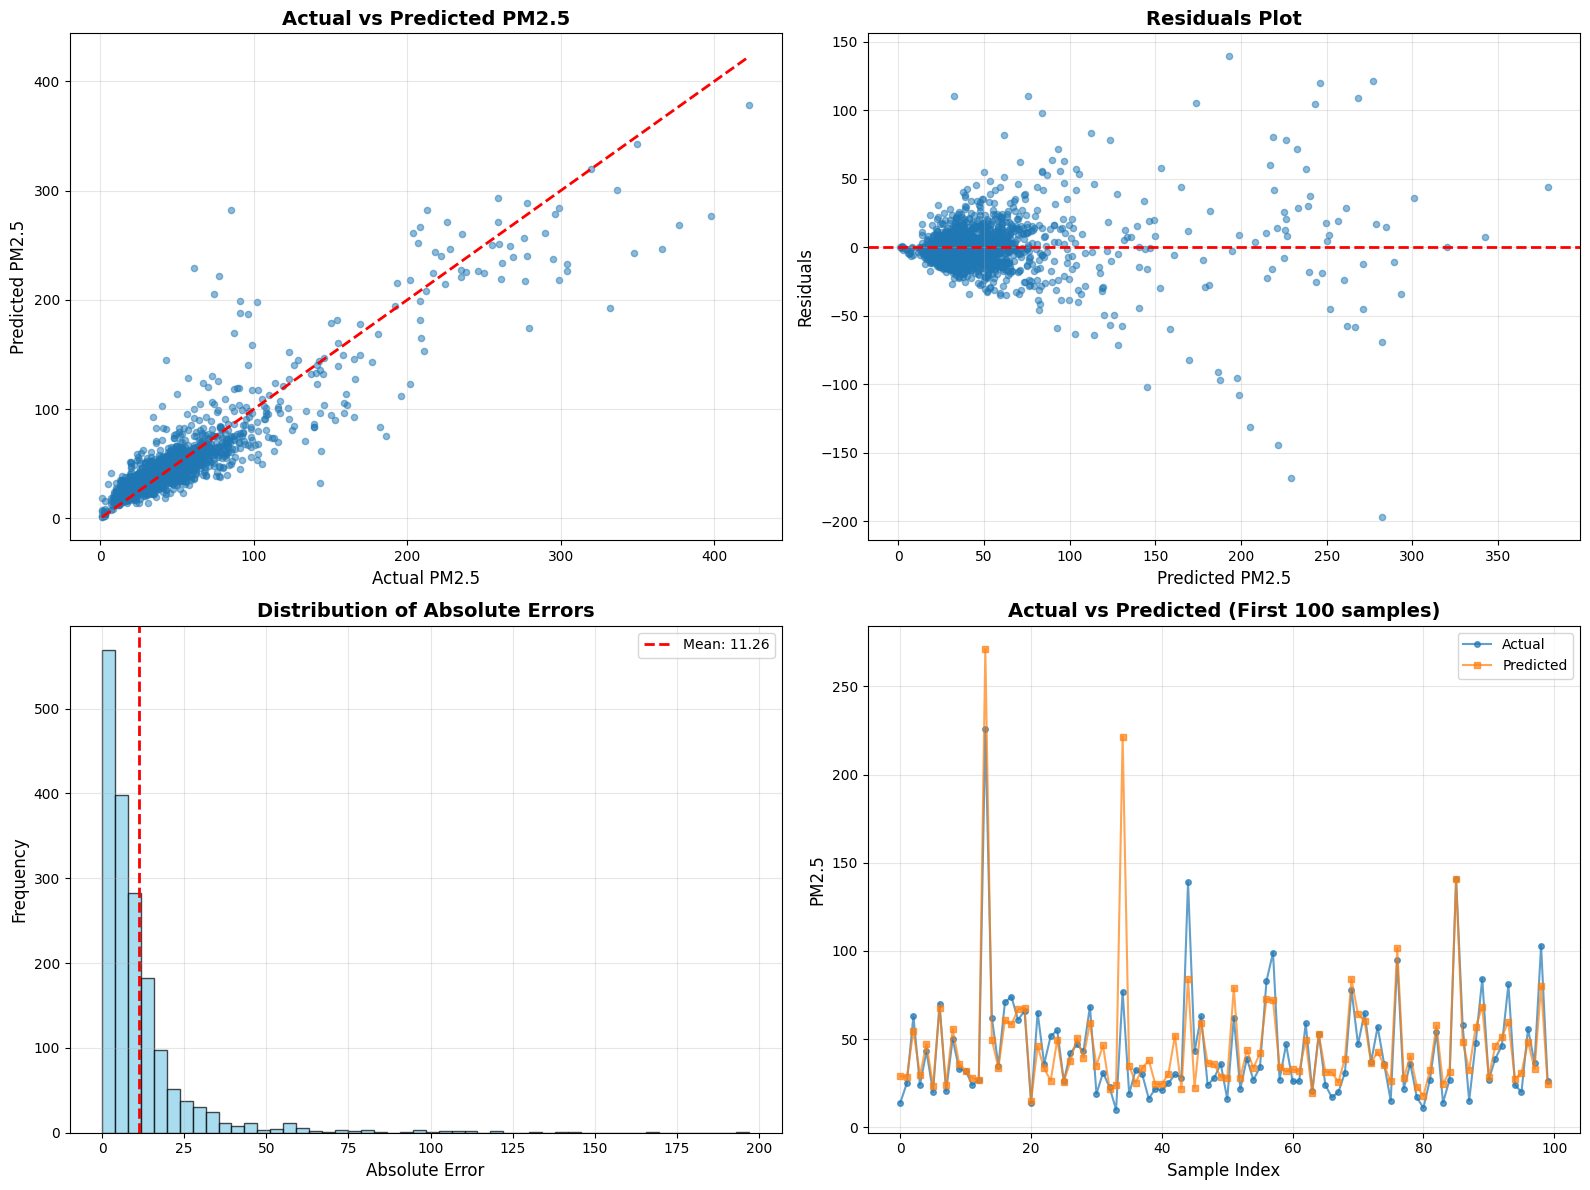


✅ Hoàn tất trực quan hóa kết quả dự đoán!


In [46]:
# Trực quan hóa kết quả dự đoán
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Scatter Plot)
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual PM2.5', fontsize=12)
axes[0, 0].set_ylabel('Predicted PM2.5', fontsize=12)
axes[0, 0].set_title('Actual vs Predicted PM2.5', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals Plot
residuals = y_test.values - y_pred_test
axes[0, 1].scatter(y_pred_test, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted PM2.5', fontsize=12)
axes[0, 1].set_ylabel('Residuals', fontsize=12)
axes[0, 1].set_title('Residuals Plot', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of Errors
axes[1, 0].hist(errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].axvline(errors.mean(), color='r', linestyle='--', lw=2, label=f'Mean: {errors.mean():.2f}')
axes[1, 0].set_xlabel('Absolute Error', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Absolute Errors', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Predicted Time Series (first 100 samples)
sample_size = min(100, len(y_test))
indices = range(sample_size)
axes[1, 1].plot(indices, y_test.values[:sample_size], 'o-', label='Actual', alpha=0.7, markersize=4)
axes[1, 1].plot(indices, y_pred_test[:sample_size], 's-', label='Predicted', alpha=0.7, markersize=4)
axes[1, 1].set_xlabel('Sample Index', fontsize=12)
axes[1, 1].set_ylabel('PM2.5', fontsize=12)
axes[1, 1].set_title(f'Actual vs Predicted (First {sample_size} samples)', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Hoàn tất trực quan hóa kết quả dự đoán!")

In [47]:
import joblib

print("=== LƯU MÔ HÌNH ===\n")

# Lưu mô hình Random Forest và scaler
joblib.dump(best_model, 'best_pm25_random_forest_model.pkl')
joblib.dump(scaler, 'pm25_scaler.pkl')

print("✅ Đã lưu mô hình:")
print("   - best_pm25_random_forest_model.pkl")
print("   - pm25_scaler.pkl")

# Tạo function để dự đoán PM2.5 cho dữ liệu mới
print("\n" + "="*60)
print("FUNCTION DỰ ĐOÁN PM2.5 CHO DỮ LIỆU MỚI")
print("="*60)

def predict_pm25(new_data):
    """
    Dự đoán PM2.5 cho dữ liệu mới.
    
    Parameters:
    -----------
    new_data : pandas DataFrame
        DataFrame chứa các đặc trưng tương tự như dữ liệu huấn luyện
        (không bao gồm cột PM25, PM10, AQI)
        
    Returns:
    --------
    predictions : numpy array
        Mảng chứa các giá trị PM2.5 dự đoán
    """
    # Load mô hình và scaler
    loaded_model = joblib.load('best_pm25_random_forest_model.pkl')
    loaded_scaler = joblib.load('pm25_scaler.pkl')
    
    # Chuẩn hóa dữ liệu mới
    new_data_scaled = loaded_scaler.transform(new_data)
    
    # Dự đoán
    predictions = loaded_model.predict(new_data_scaled)
    
    return predictions

print("\n📝 Cách sử dụng:")
print("   predictions = predict_pm25(new_data)")
print("\n   new_data phải có các cột:", list(X_train.columns))

# Test function với 5 mẫu từ tập test
print("\n" + "="*60)
print("TEST FUNCTION VỚI 5 MẪU TỪ TẬP TEST")
print("="*60)

test_samples = X_test.iloc[:5]
test_predictions = predict_pm25(test_samples)

test_results = pd.DataFrame({
    'Actual PM2.5': y_test.iloc[:5].values,
    'Predicted PM2.5': test_predictions,
    'Absolute Error': np.abs(y_test.iloc[:5].values - test_predictions)
})

print(test_results.round(2))
print(f"\n✅ Function hoạt động tốt! Sai số trung bình: {test_results['Absolute Error'].mean():.2f}")

print("\n" + "="*60)
print("🎉 HOÀN TẤT! MÔ HÌNH ĐÃ SẴN SÀNG SỬ DỤNG!")
print("="*60)

=== LƯU MÔ HÌNH ===

✅ Đã lưu mô hình:
   - best_pm25_random_forest_model.pkl
   - pm25_scaler.pkl

FUNCTION DỰ ĐOÁN PM2.5 CHO DỮ LIỆU MỚI

📝 Cách sử dụng:
   predictions = predict_pm25(new_data)

   new_data phải có các cột: ['CO', 'NO2', 'O3', 'SO2', 'Clouds', 'Precipitation', 'Pressure', 'Relative Humidity', 'Temperature', 'UV Index', 'Wind Speed', 'Hour', 'Day', 'Month', 'Year']

TEST FUNCTION VỚI 5 MẪU TỪ TẬP TEST
   Actual PM2.5  Predicted PM2.5  Absolute Error
0          14.0            44.76           30.76
1          25.0            44.87           19.87
2          63.0            39.43           23.57
3          24.0            44.83           20.83
4          43.0            44.92            1.92

✅ Function hoạt động tốt! Sai số trung bình: 19.39

🎉 HOÀN TẤT! MÔ HÌNH ĐÃ SẴN SÀNG SỬ DỤNG!


c:\Users\63200744\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
